# Importar dataset.

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("/content/drive/MyDrive/Machine Learning - Python/Datasets - Machine Learning/wine/winequality-red.csv", sep = ';')

In [3]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [4]:
import matplotlib.pyplot as plt

(array([ 10.,   0.,  53.,   0., 681.,   0., 638.,   0., 199.,  18.]),
 array([3. , 3.5, 4. , 4.5, 5. , 5.5, 6. , 6.5, 7. , 7.5, 8. ]),
 <BarContainer object of 10 artists>)

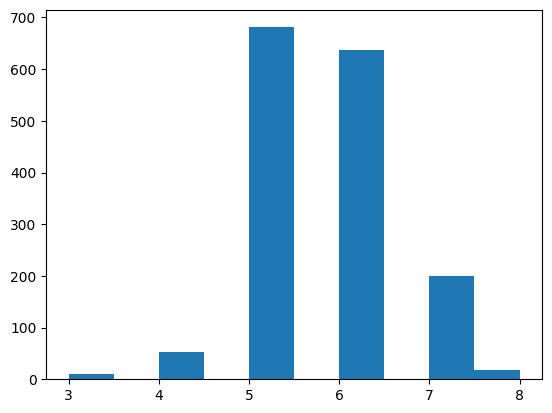

In [5]:
plt.hist(df['quality'])

In [6]:
df.groupby('quality').mean()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
quality,,,,,,,,,,,
3,8.360000,0.884500,0.171000,2.635000,0.122500,11.000000,24.900000,0.997464,3.398000,0.570000,9.955000
4,7.779245,0.693962,0.174151,2.694340,0.090679,12.264151,36.245283,0.996542,3.381509,0.596415,10.265094
5,8.167254,0.577041,0.243686,2.528855,0.092736,16.983847,56.513950,0.997104,3.304949,0.620969,9.899706
6,8.347179,0.497484,0.273824,2.477194,0.084956,15.711599,40.869906,0.996615,3.318072,0.675329,10.629519
7,8.872362,0.403920,0.375176,2.720603,0.076588,14.045226,35.020101,0.996104,3.290754,0.741256,11.465913
8,8.566667,0.423333,0.391111,2.577778,0.068444,13.277778,33.444444,0.995212,3.267222,0.767778,12.094444


# Debemos NORMALIZAR el dataset!!

In [7]:
df_norm = (df - df.min()) / (df.max() - df.min())

In [8]:
df_norm

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,0.247788,0.397260,0.00,0.068493,0.106845,0.140845,0.098940,0.567548,0.606299,0.137725,0.153846,0.4
1,0.283186,0.520548,0.00,0.116438,0.143573,0.338028,0.215548,0.494126,0.362205,0.209581,0.215385,0.4
2,0.283186,0.438356,0.04,0.095890,0.133556,0.197183,0.169611,0.508811,0.409449,0.191617,0.215385,0.4
3,0.584071,0.109589,0.56,0.068493,0.105175,0.225352,0.190813,0.582232,0.330709,0.149701,0.215385,0.6
4,0.247788,0.397260,0.00,0.068493,0.106845,0.140845,0.098940,0.567548,0.606299,0.137725,0.153846,0.4
...,...,...,...,...,...,...,...,...,...,...,...,...
1594,0.141593,0.328767,0.08,0.075342,0.130217,0.436620,0.134276,0.354626,0.559055,0.149701,0.323077,0.4
1595,0.115044,0.294521,0.10,0.089041,0.083472,0.535211,0.159011,0.370778,0.614173,0.257485,0.430769,0.6
1596,0.150442,0.267123,0.13,0.095890,0.106845,0.394366,0.120141,0.416300,0.535433,0.251497,0.400000,0.6
1597,0.115044,0.359589,0.12,0.075342,0.105175,0.436620,0.134276,0.396476,0.653543,0.227545,0.276923,0.4


# Clustering jerarquico con scikit-learn

In [9]:
from sklearn.cluster import AgglomerativeClustering

In [10]:
clus = AgglomerativeClustering(n_clusters = 6, linkage = 'ward').fit(df_norm)

In [11]:
md_h = pd.Series(clus.labels_)

In [12]:
md_h

0       2
1       2
2       2
3       3
4       2
       ..
1594    4
1595    4
1596    4
1597    4
1598    0
Length: 1599, dtype: int64

Text(0, 0.5, 'Número de vinos en el cluster')

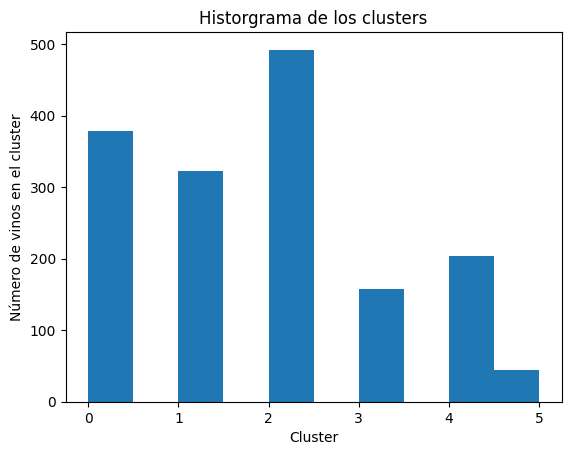

In [13]:
plt.hist(md_h)
plt.title('Historgrama de los clusters')
plt.xlabel('Cluster')
plt.ylabel('Número de vinos en el cluster')

In [14]:
clus.children_

array([[   0,    4],
       [ 135,  140],
       [ 750,  751],
       ...,
       [3179, 3191],
       [3192, 3193],
       [3194, 3195]])

In [15]:
from scipy.cluster.hierarchy import dendrogram, linkage

In [16]:
Z = linkage(df_norm, 'ward')

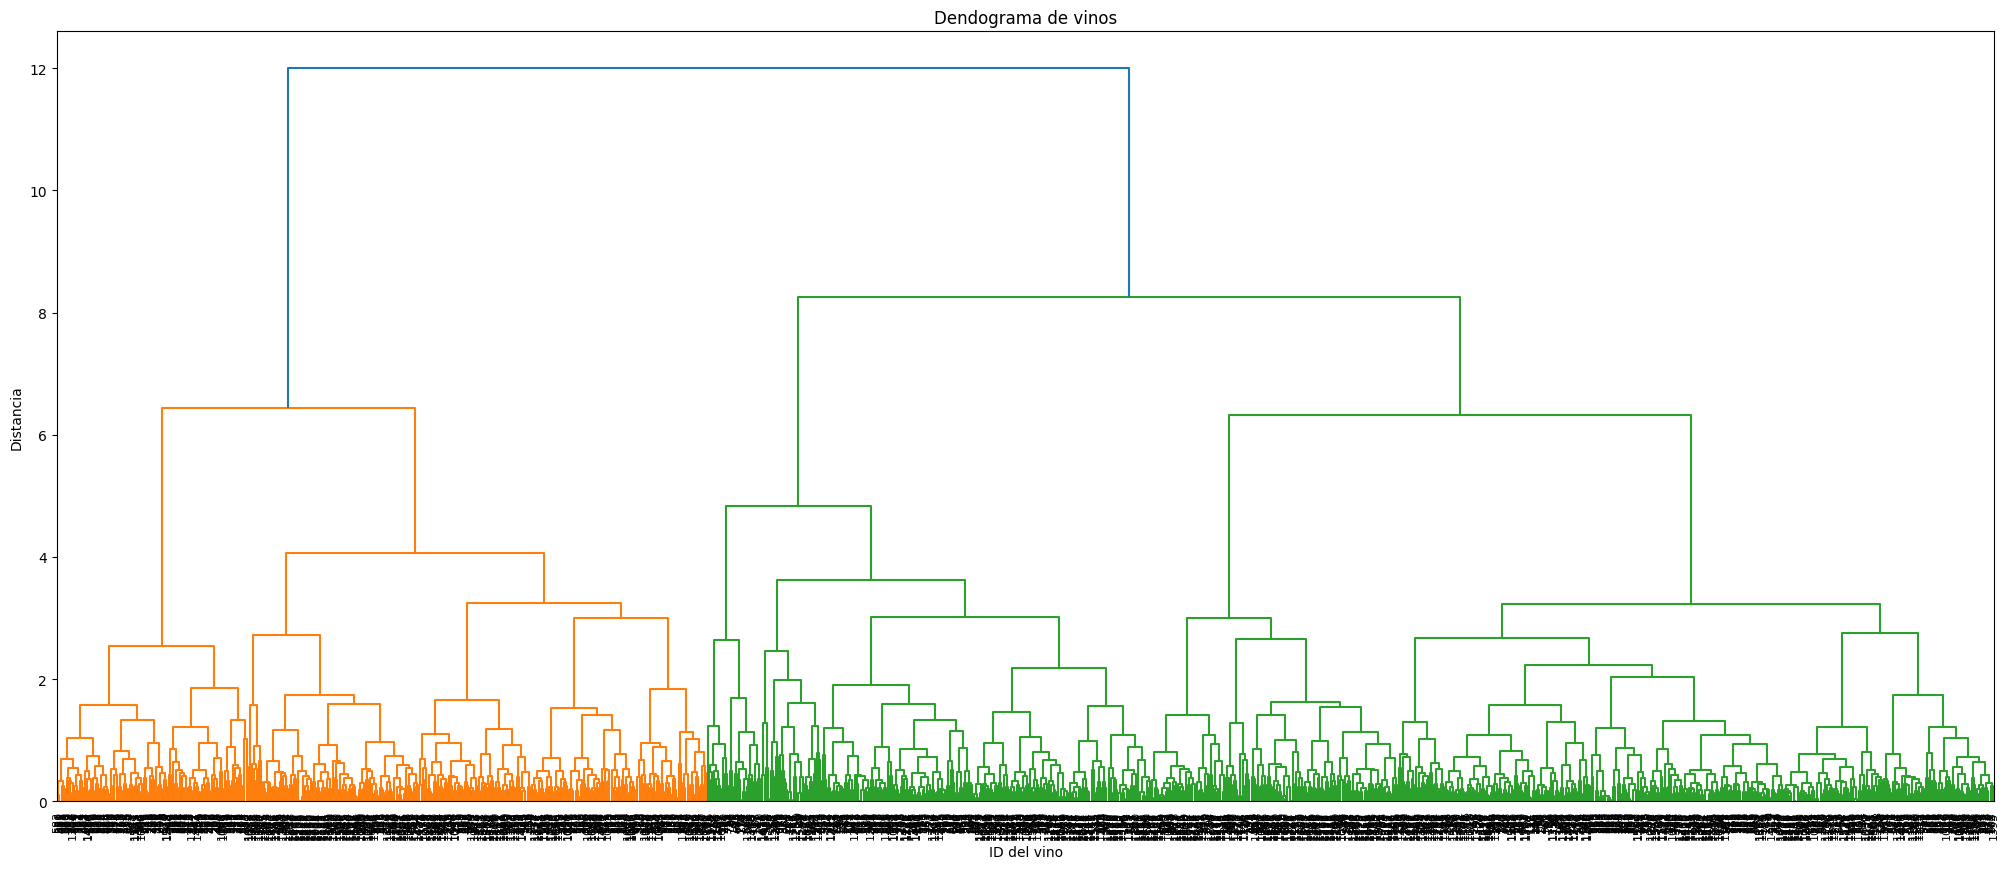

In [17]:
plt.figure(figsize = (25, 10))
plt.title('Dendograma de vinos')
plt.xlabel('ID del vino')
plt.ylabel('Distancia')
dendrogram(Z, leaf_rotation = 90., leaf_font_size = 8.)
plt.show()

# Ahora, hagamos estos análisis con el método k-means.

In [18]:
from sklearn.cluster import KMeans
from sklearn import datasets

In [19]:
model = KMeans(n_clusters = 6)
model.fit(df_norm)

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


KMeans(n_clusters=6)

In [20]:
model.labels_

array([3, 3, 3, ..., 2, 2, 5], dtype=int32)

In [21]:
md_k = pd.Series(model.labels_)

In [22]:
df_norm['clust_h'] = md_h
df_norm['clust_k'] = md_k

In [23]:
df_norm.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,clust_h,clust_k
0,0.247788,0.397260,0.00,0.068493,0.106845,0.140845,0.098940,0.567548,0.606299,0.137725,0.153846,0.4,2,3
1,0.283186,0.520548,0.00,0.116438,0.143573,0.338028,0.215548,0.494126,0.362205,0.209581,0.215385,0.4,2,3
2,0.283186,0.438356,0.04,0.095890,0.133556,0.197183,0.169611,0.508811,0.409449,0.191617,0.215385,0.4,2,3
3,0.584071,0.109589,0.56,0.068493,0.105175,0.225352,0.190813,0.582232,0.330709,0.149701,0.215385,0.6,3,4
4,0.247788,0.397260,0.00,0.068493,0.106845,0.140845,0.098940,0.567548,0.606299,0.137725,0.153846,0.4,2,3


(array([ 35.,   0., 331.,   0., 218.,   0., 492.,   0., 255., 268.]),
 array([0. , 0.5, 1. , 1.5, 2. , 2.5, 3. , 3.5, 4. , 4.5, 5. ]),
 <BarContainer object of 10 artists>)

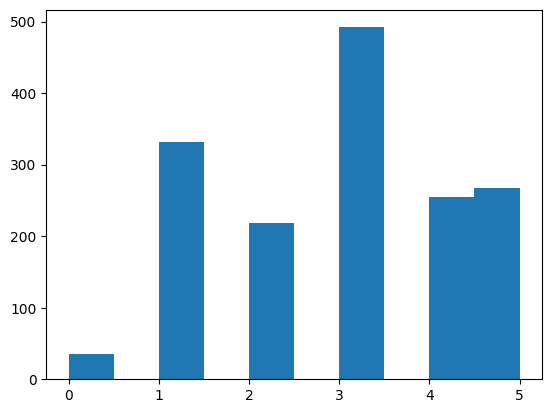

In [24]:
plt.hist(md_k)

In [28]:
model.cluster_centers_

array([[0.17232055, 0.32626205, 0.08851852, 0.09379756, 0.09505039,
        0.25045644, 0.12401845, 0.32144994, 0.58264071, 0.18651586,
        0.49510921, 0.61388889],
       [0.26319956, 0.36051499, 0.11737575, 0.09160789, 0.12273604,
        0.14399518, 0.10654097, 0.49017788, 0.48690534, 0.15495054,
        0.22168018, 0.44015905],
       [0.58242935, 0.20579706, 0.51197581, 0.13400354, 0.13117965,
        0.13908451, 0.09183005, 0.65596431, 0.33194691, 0.22249855,
        0.29185277, 0.54758065],
       [0.36148029, 0.16073474, 0.41854545, 0.10438356, 0.10601912,
        0.15984635, 0.08353357, 0.41547991, 0.42073014, 0.23560152,
        0.47865734, 0.69090909],
       [0.31428107, 0.27776381, 0.30159021, 0.14965858, 0.12649012,
        0.37840806, 0.29420473, 0.53665908, 0.43812757, 0.17828563,
        0.21480436, 0.45626911],
       [0.33716814, 0.29223744, 0.48133333, 0.07557078, 0.53789649,
        0.20938967, 0.21071849, 0.5143906 , 0.2335958 , 0.59001996,
        0.16512821,

In [25]:
model.inertia_

187.441759556918

# Interpretación

In [29]:
df_norm.groupby('clust_h').mean()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,clust_k
clust_h,,,,,,,,,,,,,
0,0.380858,0.171341,0.422691,0.109661,0.109928,0.178844,0.098362,0.450974,0.417198,0.226202,0.439821,0.653298,4.377309
1,0.311109,0.282598,0.299255,0.159683,0.126075,0.349926,0.283037,0.545567,0.441899,0.174080,0.203376,0.450932,1.295031
2,0.265613,0.356714,0.113557,0.091213,0.124109,0.147873,0.105073,0.486659,0.485132,0.156005,0.228685,0.455285,2.908537
3,0.644449,0.206477,0.548734,0.128576,0.124564,0.142271,0.098135,0.684780,0.301455,0.226218,0.296754,0.559494,4.000000
4,0.169313,0.344531,0.080000,0.089394,0.095731,0.253521,0.122151,0.329572,0.589432,0.182165,0.482944,0.578431,2.058824
5,0.335881,0.279577,0.405455,0.069894,0.430073,0.172535,0.184388,0.508911,0.274875,0.517148,0.171678,0.450000,1.000000


In [30]:
df_norm.groupby('clust_k').mean()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,clust_h
clust_k,,,,,,,,,,,,,
0,0.358534,0.290313,0.483143,0.181213,0.493251,0.284507,0.239778,0.574890,0.250169,0.554491,0.149890,0.462857,4.314286
1,0.309521,0.283864,0.288248,0.131772,0.123862,0.362836,0.285493,0.529925,0.440374,0.173834,0.210303,0.447130,1.111782
2,0.172972,0.323866,0.090963,0.093408,0.095074,0.251292,0.125928,0.320569,0.581088,0.186892,0.494872,0.613761,3.472477
3,0.263454,0.360758,0.116646,0.092389,0.123828,0.139285,0.101016,0.491237,0.487645,0.155299,0.223853,0.443089,2.034553
4,0.577512,0.202055,0.505882,0.129868,0.130381,0.136205,0.089947,0.653010,0.335958,0.224023,0.289090,0.548235,1.980392
5,0.361016,0.160103,0.428172,0.114138,0.105580,0.175005,0.095789,0.411311,0.418939,0.234985,0.489036,0.698507,0.126866
